# Data Mining 2026  — Project Notebook

**Course:** Data Mining  

**Project track:** ☐ Standard Analysis 

**Group members: Group 16**  
- Giancarlo Marchesini  
- Himan Kalita  
- Kris Kraack  

**Dataset:**  Bike Sharing 

**Initial task description (Module 1 perspective):**
+ Given the nature of the information reported in the dataset 'Bike Sharing' we *Group 16* want to study this 3 tasks:
    - Commuter Identification : The dataset(s) provide the information if the user of the service is casual or registered, this give the right intuition to hypotize that the affluence of one or another type user must be correlated to particular rental patterns. Clustering algorithms such as k-means or k-medoids can be employed for the classification of the user.

    - Weather correlation with sharing activity : In the dataset are reported many meteorological factors recorded at the moment of the rental service so we want to exploit this information to study if there is any correlation between the weather and the sharing activity. Then clustering can be designed to identify groups of weather patterns that lead to similar bike rental activities.

    - Anomaly detection: The bike sharing activity is recorded in Washington D.C. , therefore could be interresting to look for anomalous behaviour maybe corrispondig to particular historical events or extreme weather. Density-based clustering, like DBSCAN, are very useful for detecting anomalies. 

- We'll proceed in the following way:
    - first we'll use some EDA tools to understand more about our dataset, those are *basic statistics* , *corr matrix*, *basic raffiguration of variables*, *density*. 
    - then we'll see the row data and understand if we can preprocess and transform it in some way to make it suitable for clustering, for example some data by itself is not very useful 
    - In the end we'll procide implementing some clustering methods to work on our tasks. 

## 0. Reproducibility and Setup

In [298]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.12.0 (v3.12.0:0fb18b02c8, Oct  2 2023, 09:45:56) [Clang 13.0.0 (clang-1300.0.29.30)]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Source: The dataset is pubblicly avaible on the website fo the bike sharing company (http://capitalbikeshare.com/system-data), the Laboratory of Artificial Intelligence and Decision Support (LIAAD) of the University of Porto managed to gather all the avaible data in 2 datasets in format .csv, each aggregated on a hourly or daily base. 
- Number of instances: 
    - 'hour.csv' : 17379;
    - 'day.csv' : 731.
- Number of features / entities: 
    - 'hour.csv' : 17;
    - 'day.csv' : 16.
- Missing values: none of the datasets have missing values.
- Basic statistics: read the next results.
- Variable description: Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv
	
	- instant: record index
	- dteday : date
	- season : season (1:springer, 2:summer, 3:fall, 4:winter)
	- yr : year (0: 2011, 1:2012)
	- mnth : month ( 1 to 12)
	- hr : hour (0 to 23)
	- holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
	- weekday : day of the week
	- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
	+ weathersit : 
		- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
		- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
		- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
		- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
	- temp : Normalized temperature in Celsius. The values are divided to 41 (max)
	- atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
	- hum: Normalized humidity. The values are divided to 100 (max)
	- windspeed: Normalized wind speed. The values are divided to 67 (max)
	- casual: count of casual users
	- registered: count of registered users
	- cnt: count of total rental bikes including both casual and registered

In [299]:
# Load dataset
data_hour = pd.read_csv('/Users/giancarlomarchesini/Desktop/Uni/Terzo anno/Secondo semestre/Data Mining/bike+sharing+dataset/hour.csv')
data_day = pd.read_csv('/Users/giancarlomarchesini/Desktop/Uni/Terzo anno/Secondo semestre/Data Mining/bike+sharing+dataset/day.csv')

# dataset overview
data_hour.head()
data_day.head()

# basic info about the datasets
data_hour.info()
data_day.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

### 1.2 Dataset Basic Statistics and EDA
- To understand the datasets is useful to start desribing them with basic statistics (mean, variance). However, those statistics by themselves are not very useful to provide us information about the decision process that anticipate data mining. Thus, we think that the implementation of the following procedures is commensurate to our goal.

             hr   holiday   weekday  workingday  weathersit      temp  \
mean  11.546752  0.028770  3.003683    0.682721    1.425283  0.496987   
std    6.914405  0.167165  2.005771    0.465431    0.639357  0.192556   

         atemp       hum  windspeed     casual  registered         cnt  
mean  0.475775  0.627229   0.190098  35.676218  153.786869  189.463088  
std   0.171850  0.192930   0.122340  49.305030  151.357286  181.387599  
       holiday   weekday  workingday  weathersit      temp     atemp  \
mean  0.028728  2.997264    0.683995    1.395349  0.495385  0.474354   
std   0.167155  2.004787    0.465233    0.544894  0.183051  0.162961   

           hum  windspeed      casual   registered          cnt  
mean  0.627894   0.190486  848.176471  3656.172367  4504.348837  
std   0.142429   0.077498  686.622488  1560.256377  1937.211452  


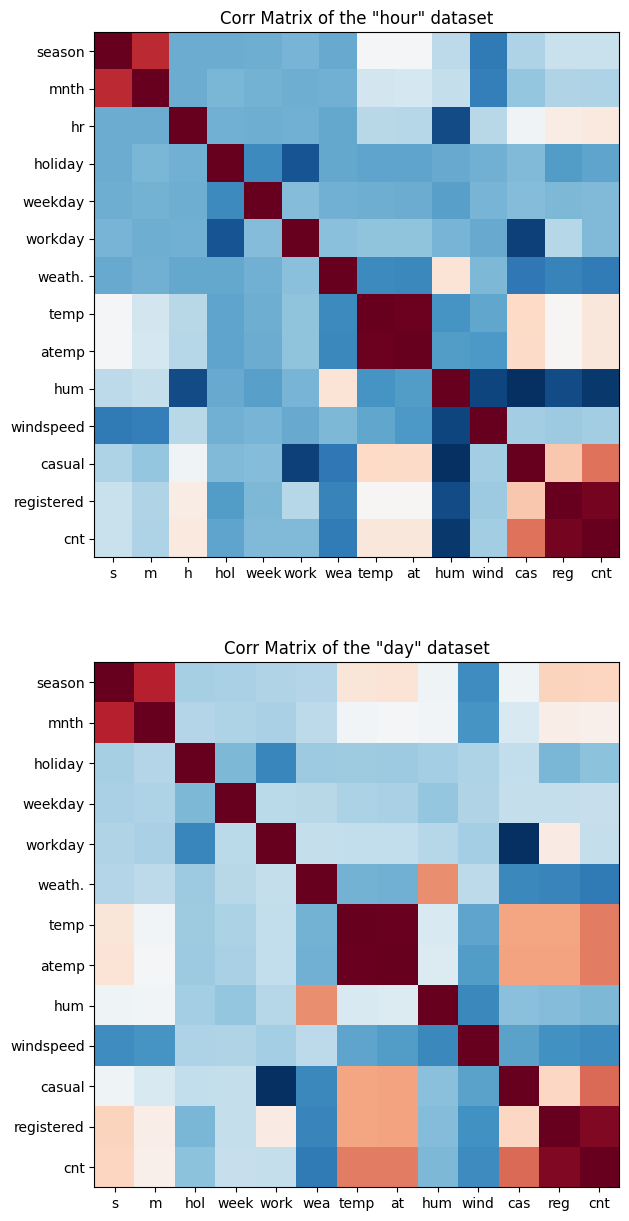

In [ ]:
# basic statistics about the datasets
print(data_hour.drop(columns=['instant', 'season', 'yr','mnth', 'dteday']).describe().drop(index = ['count','min', '50%' ,'25%', '75%', 'max']))
print(data_day.drop(columns=['instant', 'season', 'yr','mnth', 'dteday']).describe().drop(index = ['count','min', '50%', '25%', '75%', 'max']))

# correlation matrixes for the two datasets

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(17,15))

ax[0].imshow(data_hour.drop(columns=['dteday','instant', 'yr']).corr(), cmap='RdBu_r' )
ax[0].set_title('Corr Matrix of the "hour" dataset')
ax[0].set_xticks(range(len(data_hour.drop(columns=['dteday','instant', 'yr']).columns)))
ax[0].set_xticklabels([ 's',  'm', 'h', 'hol', 'week', 'work', 'wea', 'temp', 'at', 'hum', 'wind', 'cas', 'reg', 'cnt'])
ax[0].set_yticks(range(len(data_hour.drop(columns=['dteday','instant', 'yr']).columns)))
ax[0].set_yticklabels([ 'season',  'mnth', 'hr', 'holiday', 'weekday', 'workday', 'weath.', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt'])


ax[1].imshow(data_day.drop(columns=['dteday','instant', 'yr']).corr(), cmap='RdBu_r', )
ax[1].set_title('Corr Matrix of the "day" dataset')
ax[1].set_xticks(range(len(data_day.drop(columns=['dteday','instant', 'yr']).columns)))
ax[1].set_xticklabels([ 's', 'm', 'hol', 'week', 'work', 'wea', 'temp', 'at', 'hum', 'wind', 'cas', 'reg', 'cnt'])
ax[1].set_yticks(range(len(data_day.drop(columns=['dteday','instant', 'yr']).columns)))
ax[1].set_yticklabels([ 'season', 'mnth', 'holiday', 'weekday', 'workday', 'weath.', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt'])
plt.show()

The correlation matrixes provide an overview of the interaction between variables. 
It's clear that the 'cnt' variable (that is the count of rentals per unit of time), assumed as 'response', is fairly correlated with all the variables related to the weather. The task 2 could be meaningful. 

Also, these matrices highlight a negative interaction between workdays and casual users, strengthening our hypotesis about different users patterns due to different type of days. 

Another thing that these matrices highlight is that 'temp' and 'atemp' are so correlated that later in the data processing phase we could combine those in one single variable. 

Note: to compute the corr. matrix it have been removed some variables that are clearly meaningless in term of correlation. (With only 2 years of recording it's clearly usless to keep the corrisponding variable, also the record index does not have meaning)

As EDA seems reasonable to start focusing on 'cnt' as response, that is to say the counter of total users per hour. 
It seems interesting to seek the hour trend during the day and the average hour trend for each month.  

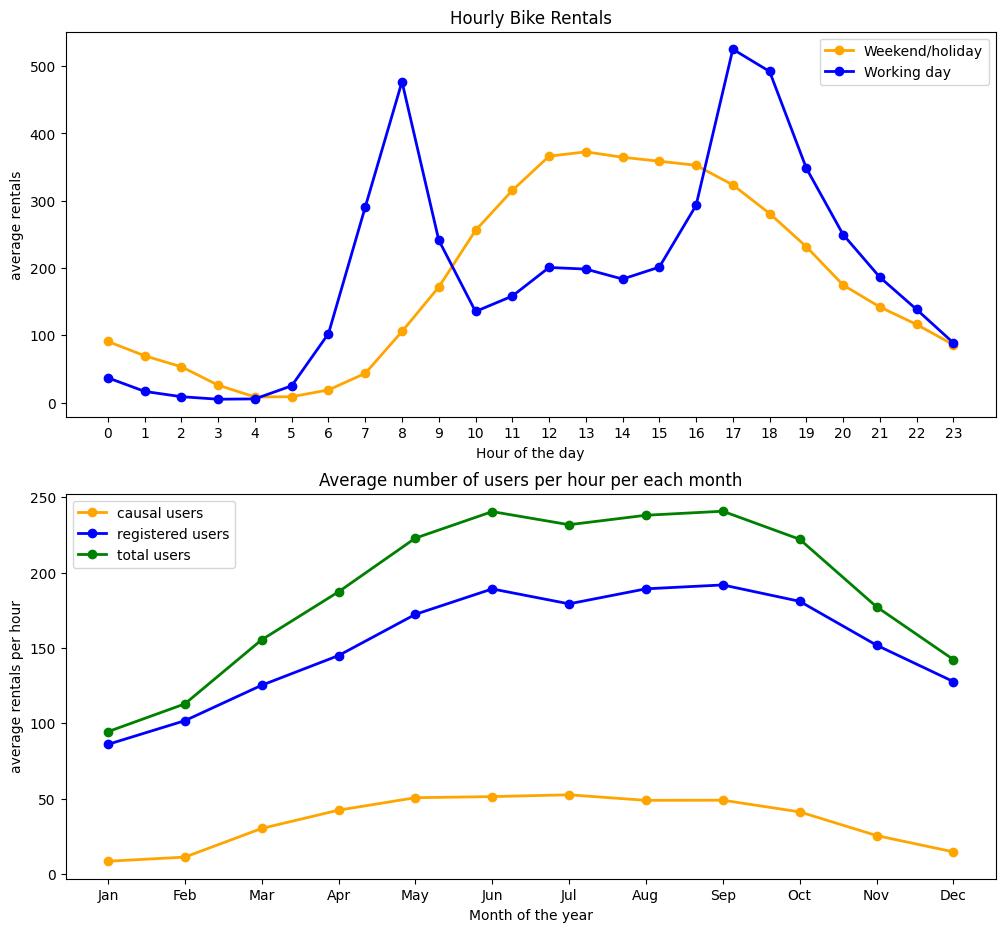

In [301]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12,11))

# plot of the hour trend 
subset = data_hour.pivot_table(index='hr', columns='workingday', values='cnt', aggfunc='mean')

axes[0].set_xlabel('Hour of the day')
axes[0].set_ylabel('average rentals')
axes[0].set_title('Hourly Bike Rentals')
axes[0].plot(subset.index ,subset[0],label='Weekend/holiday', color='orange', linewidth=2, marker='o')
axes[0].plot(subset.index ,subset[1],label='Working day', color='blue', linewidth=2, marker='o')
axes[0].set_xticks(range(0, 24))
axes[0].legend()
# plot of the average hour users by month   
subset_m = data_hour.pivot_table(index='mnth', values = ['casual','registered','cnt'], aggfunc='mean')
axes[1].set_xlabel('Month of the year')
axes[1].set_ylabel('average rentals per hour')
axes[1].set_title('Average number of users per hour per each month')
axes[1].plot(subset_m.index, subset_m['casual'], label = 'causal users' ,color='orange',linewidth=2, marker='o')
axes[1].plot(subset_m.index, subset_m['registered'], label = 'registered users' ,color='blue',linewidth=2, marker='o')
axes[1].plot(subset_m.index, subset_m['cnt'], label = 'total users' ,color='green',linewidth=2, marker='o')

axes[1].set_xticks(subset_m.index)
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].legend()
plt.show()


Those plots are useful to strengthen the fact that there should be clusters distinguishing different types of the users.

The first plot highlights the fact that the traffic distribution by hour is different during the workdays and weekdays, suggesting a stronger distinction between habits (and patterns) of casual users and registered users. 
Indeed during weekdays there are more rentals during rush hours, suggesting a predominance of commuters that benefit from this service. 
While during the weekend days and holidays the rentals are more evenly spread during all the afternoon with a peak at 12/13, suggesting more touristical and casual activities.

The second plot shows an increasing of shering activities both in casual and registred users in the warmer months, suggesting a simple correlation between the general weather and the amount of users. 

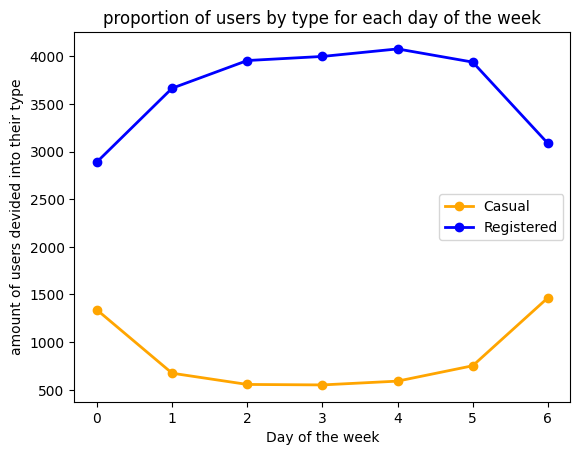

In [302]:
# plot of the hour trend 
subset_day_1 = data_day.pivot_table(index='weekday', values=['casual', 'registered'], aggfunc='mean')

plt.xlabel('Day of the week')
plt.ylabel('amount of users devided into their type')
plt.title('proportion of users by type for each day of the week')
plt.plot(subset_day_1.index ,subset_day_1['casual'],label='Casual', color='orange', linewidth=2, marker='o')
plt.plot(subset_day_1.index ,subset_day_1['registered'],label='Registered', color='blue', linewidth=2, marker='o')
plt.xticks(range(0, 7))
plt.legend()

This last plot make the already discussed hypotesis of distinguish users stronger. 

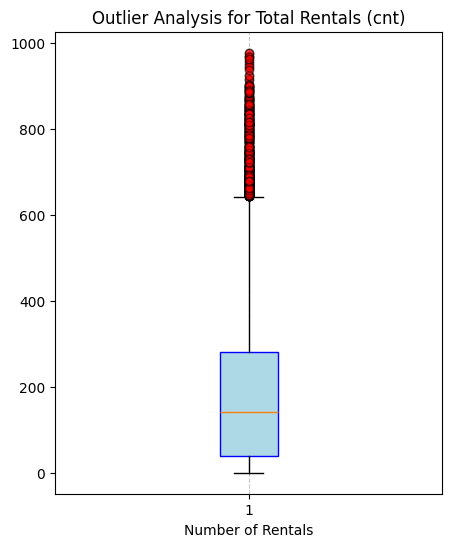

In [303]:

# Boxplot for the outlier analysis of the target variable 'cnt' 
plt.figure(figsize=(5, 6))
plt.boxplot(data_hour['cnt'], vert=True, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', color='blue'),
            flierprops=dict(marker='o', markerfacecolor='red', alpha=0.5))

plt.title('Outlier Analysis for Total Rentals (cnt)')
plt.xlabel('Number of Rentals')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

This simple boxplot based on hour recordings shows that there are many anomalous observation. Task 3 could be motivated.
We can try to group the outliers by weather events and see if they are somehow correlated.

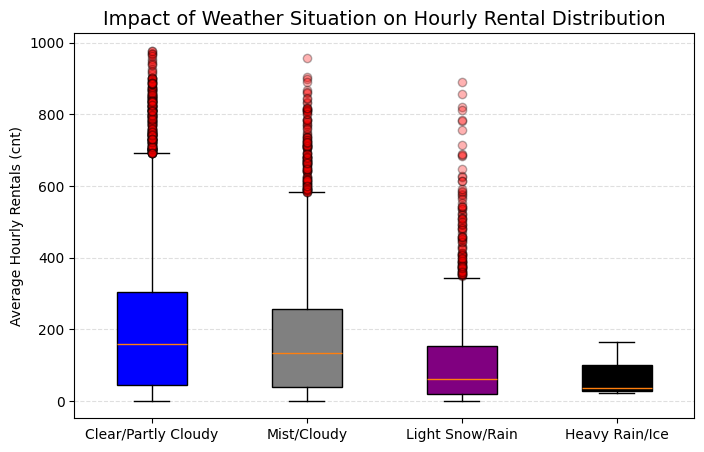

In [392]:

weather_types = {
    1: 'Clear/Partly Cloudy',
    2: 'Mist/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
}
weather_groups = [data_hour[data_hour['weathersit'] == i]['cnt'] for i in range(1, 5)]
plt.figure(figsize=(8, 5))
bp = plt.boxplot(weather_groups, tick_labels=weather_types.values(), patch_artist=True,
                 flierprops=dict(marker='o', markerfacecolor='red', alpha=0.3))
colors = ['Blue', 'Grey', 'Purple', 'Black'] 
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Impact of Weather Situation on Hourly Rental Distribution', fontsize=14)
plt.ylabel('Average Hourly Rentals (cnt)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

The correlation matric 

It is clear that not only the number of anomalus events but also the general number of users is affected by the weather.

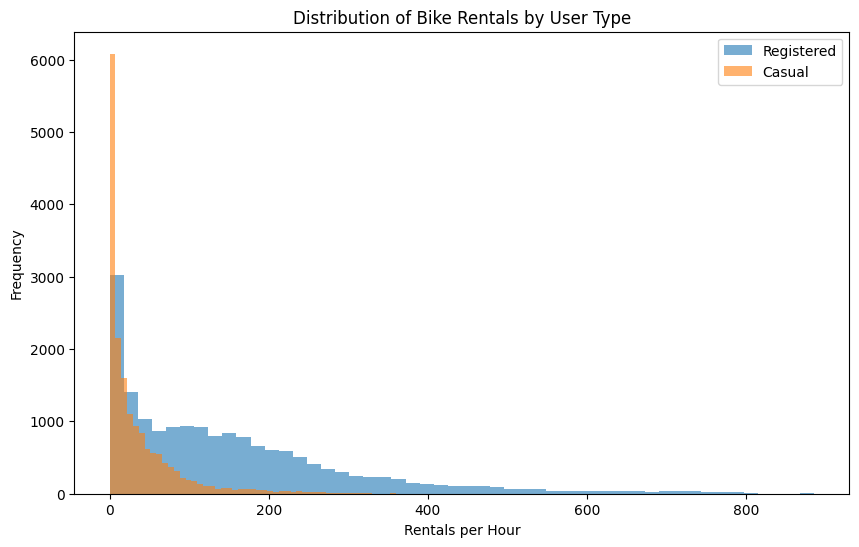

In [305]:
plt.figure(figsize=(10,6))

plt.hist(data_hour['registered'], bins=50, alpha=0.6, label='Registered')
plt.hist(data_hour['casual'], bins=50, alpha=0.6, label='Casual')

plt.title('Distribution of Bike Rentals by User Type')
plt.xlabel('Rentals per Hour')
plt.ylabel('Frequency')
plt.legend()

plt.show()

There is clearly a dinstinction between the dinstribution of the casual users and registered. 

'Sparsity' means that most values in the dataset are zero or missing. We compute this simple code to quantify ho many objects in the data matrix are 0. 

In [306]:
#sparsity 
sparsity = (data_hour == 0).sum().sum() / data_hour.size
density = 1 - sparsity

print("Sparsity:", sparsity)
print("Density:", density)

Sparsity: 0.1288742667790403
Density: 0.8711257332209597


The dataset is very dense so we rejcet the hypotesis of sparsity 

How many missing values do we have in the dataset? 

In [307]:
missing_ratio = data_hour.isnull().sum().sum() / data_hour.size
print("Missing value ratio:", missing_ratio)

Missing value ratio: 0.0


As expected there are no mussung values.

Factor Loadings:
             Factor1   Factor2   Factor3   Factor4   Factor5
season      0.329052 -0.239919  0.800578 -0.022582 -0.006397
yr          0.040696  0.081366 -0.000774  0.009089 -0.037660
mnth        0.218516 -0.251592  0.872354  0.005778  0.024030
hr          0.138473  0.269510  0.027097  0.000569  0.115207
holiday    -0.029704  0.012079  0.026537  0.782925 -0.000711
weekday    -0.005628  0.036451  0.017931 -0.129722  0.024495
workingday  0.054925 -0.019291 -0.021104 -0.319585  0.012640
weathersit -0.109836 -0.409074 -0.091815 -0.023788  0.237453
temp        0.992525  0.003881 -0.017028  0.002764  0.032558
atemp       0.995538 -0.015260 -0.014804 -0.000765 -0.018931
hum        -0.068175 -0.980296 -0.077448  0.001805  0.008055
windspeed  -0.046737  0.309846 -0.070712  0.005161  0.616408

Variance Explained by Factors:
         Variance  Proportion  Cumulative
Factor1  2.175885    0.181324    0.181324
Factor2  1.426537    0.118878    0.300202
Factor3  1.424070    0.118673   

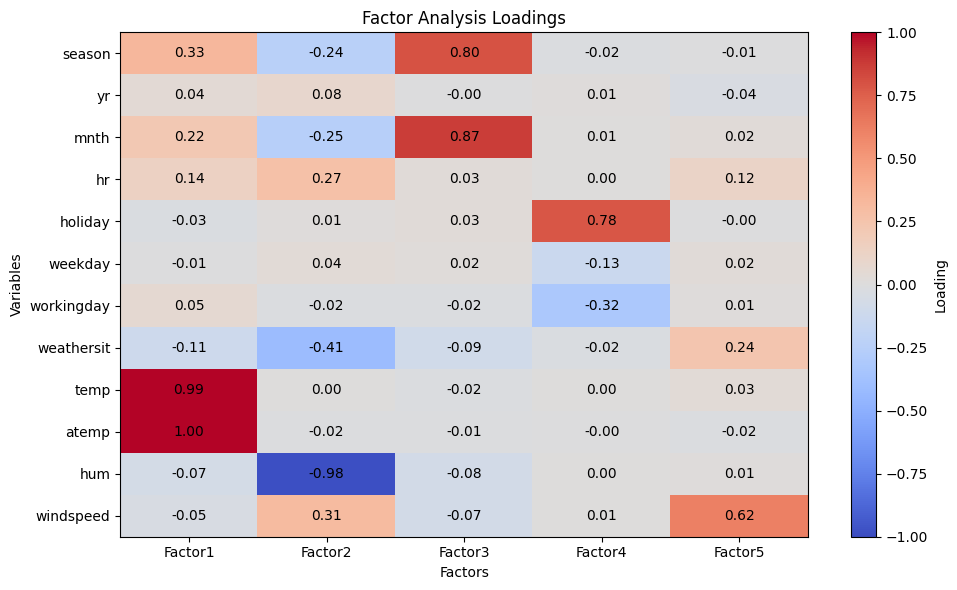

Factor Loadings:
             Factor1   Factor2   Factor3   Factor4   Factor5
season     -0.350489  0.823996 -0.190171 -0.028528  0.003985
yr         -0.046575 -0.041206 -0.104444 -0.005420  0.015846
mnth       -0.235791  0.867755 -0.177082  0.001673  0.032732
holiday     0.030636  0.010729 -0.038442  0.572061  0.266583
weekday     0.004004 -0.004474 -0.032146 -0.174063  0.019296
workingday -0.052539 -0.006192  0.050364 -0.367915 -0.139190
weathersit  0.119848  0.221012  0.690671 -0.151039  0.234067
temp       -0.995869 -0.018435 -0.002707 -0.006272  0.019495
atemp      -0.996091 -0.006517  0.005046  0.005904 -0.017615
hum        -0.137893  0.379440  0.792494  0.063570 -0.062650
windspeed   0.174832 -0.235963 -0.112301 -0.209878  0.493051

Variance Explained by Factors:
         Variance  Proportion  Cumulative
Factor1  2.232220    0.202929    0.202929
Factor2  1.682723    0.152975    0.355904
Factor3  1.201196    0.109200    0.465104
Factor4  0.564736    0.051340    0.516443
Factor5  

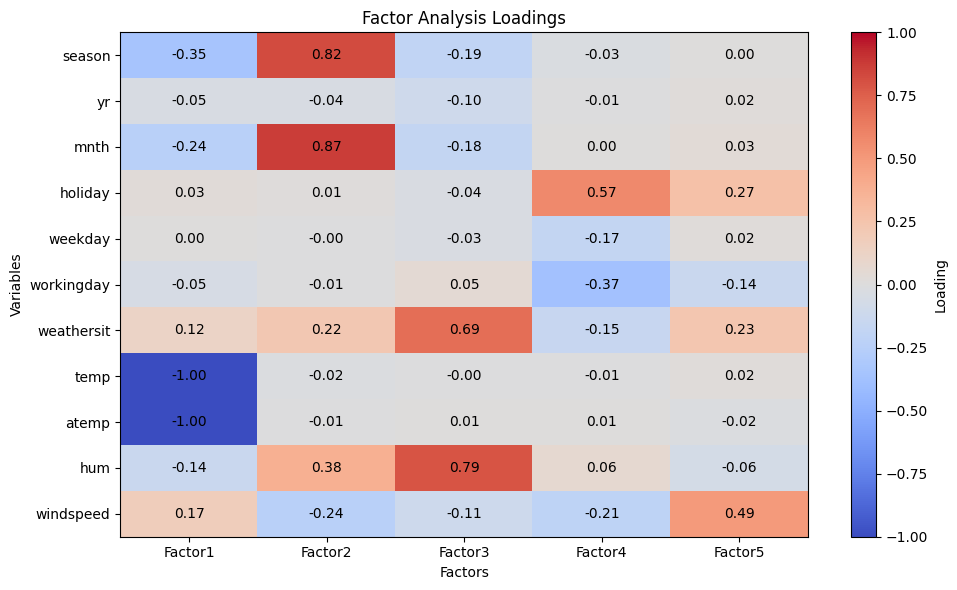

,Factor1,Factor2,Factor3,Factor4,Factor5
season,-0.350489,0.823996,-0.190171,-0.028528,0.003985
yr,-0.046575,-0.041206,-0.104444,-0.005420,0.015846
mnth,-0.235791,0.867755,-0.177082,0.001673,0.032732
holiday,0.030636,0.010729,-0.038442,0.572061,0.266583
weekday,0.004004,-0.004474,-0.032146,-0.174063,0.019296
workingday,-0.052539,-0.006192,0.050364,-0.367915,-0.139190
weathersit,0.119848,0.221012,0.690671,-0.151039,0.234067
temp,-0.995869,-0.018435,-0.002707,-0.006272,0.019495
atemp,-0.996091,-0.006517,0.005046,0.005904,-0.017615
hum,-0.137893,0.379440,0.792494,0.063570,-0.062650


In [ ]:
from sklearn.decomposition import FactorAnalysis

def run_factor_analysis(df, drop_cols=None, n_factors= 5):
    if drop_cols is None:
        drop_cols = []
    X = df.drop(columns=drop_cols, errors='ignore')

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    fa = FactorAnalysis(n_components=n_factors, random_state=42, max_iter=2000)
    fa.fit_transform(X_scaled)
    loadings = pd.DataFrame(
        fa.components_.T,
        columns=[f"Factor{i+1}" for i in range(n_factors)],
        index=X.columns
    )

    print("Factor Loadings:")
    print(loadings)
    
    variance_explained = (loadings ** 2).sum(axis=0)
    prop_variance = variance_explained / len(X.columns)

    variance_table = pd.DataFrame({
        "Variance": variance_explained,
        "Proportion": prop_variance,
        "Cumulative": prop_variance.cumsum()
    })

    print("\nVariance Explained by Factors:")
    print(variance_table)
    
    plt.figure(figsize=(10,6))
    plt.imshow(loadings, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(label='Loading')
    plt.xticks(ticks=np.arange(n_factors), labels=[f"Factor{i+1}" for i in range(n_factors)])
    plt.yticks(ticks=np.arange(len(X.columns)), labels=X.columns)
    
    for i in range(len(X.columns)):
        for j in range(n_factors):
            plt.text(j, i, f"{loadings.iloc[i,j]:.2f}", ha='center', va='center', color='black')

    plt.title("Factor Analysis Loadings")
    plt.xlabel("Factors")
    plt.ylabel("Variables")
    plt.tight_layout()
    plt.show()

    return loadings

drop_cols = ["instant", "dteday", "casual", "registered", "cnt"]

run_factor_analysis(data_hour, drop_cols=drop_cols, n_factors=5)
run_factor_analysis(data_day, drop_cols=drop_cols, n_factors=5)


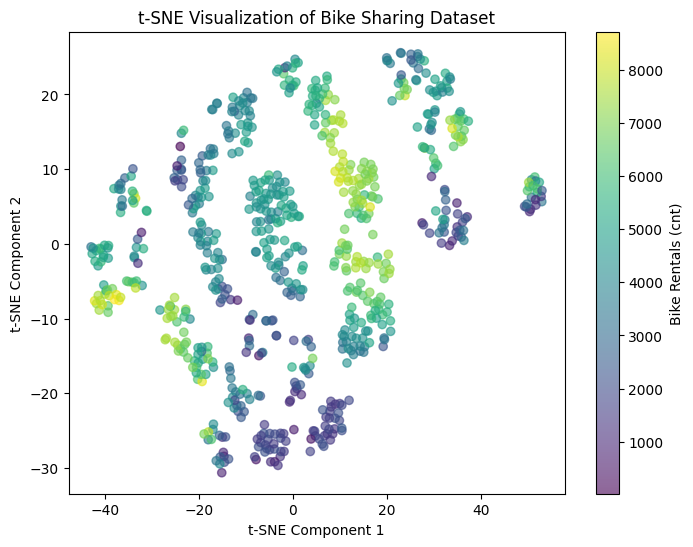

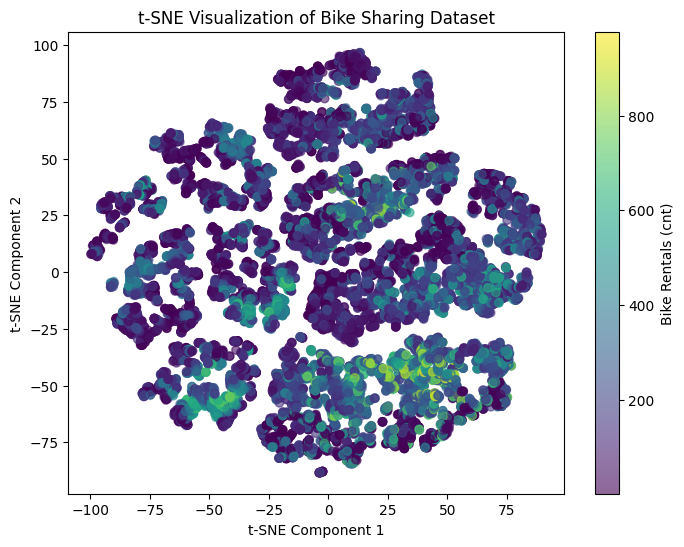

In [309]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def t_SNE(d ,Y , drop_cols):
    X = d.drop(columns=drop_cols)
    y = d[Y]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=10)
    X_pca = pca.fit_transform(X_scaled)
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42 )
    X_tsne = tsne.fit_transform(X_pca)

    plt.figure(figsize=(8,6))
    plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="viridis", alpha=0.6)
    plt.colorbar(label="Bike Rentals (cnt)")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.title("t-SNE Visualization of Bike Sharing Dataset")
    plt.show()
   
 
drop_cols = ["instant","dteday","casual","registered","cnt"]
Y = "cnt"
t_SNE(data_day, Y, drop_cols)
t_SNE(data_hour, Y, drop_cols)

The t-SNE representation is achieved after performing PCA dimensional reduction. The PCA reduces extraneous or overlapping data thereby aiding both the accuracy and computational speed of the t-SNE processing. In the graph each point rappresent an hourly observation and shows the count of rentals (cnt) for each observation through colour gradients. 
In both final plots about day and hour recordings is clear that there are some clustering opportunities.

Thus, this visualisation highlights non-linear relationships between rental demand across hours, which would not be easily evident when looking at simple histograms or through the use of standard linear projections. It also provides more detail about how the demand for rentals is structured on an hourly basis.

### 1.3 Cleaning & Transformations
- Handling missing values: the provider of the dataset says that the datasets don't have asny missing values.
- Feature engineering: 

In [ ]:
############## ???????????????

def Fe(d):
    X = d
    
    # ciclical time features ? 
    if 'hr' in X.columns:
        X['hr_sin'] = np.sin(2 * np.pi * X['hr'] / 24)
        X['hr_cos'] = np.cos(2 * np.pi * X['hr'] / 24)
        X = X.drop(columns=['hr'])
    if 'weekday' in X.columns:
        X['weekday_sin'] = np.sin(2 * np.pi * X['weekday'] / 7)
        X['weekday_cos'] = np.cos(2 * np.pi * X['weekday'] / 7)
        X = X.drop(columns=['weekday'])
    if 'mnth' in X.columns:
        X['month_sin'] = np.sin(2 * np.pi * X['mnth'] / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['mnth'] / 12)
        X = X.drop(columns=['mnth'])
        
    # Create average temperature feature
    X['temp_comb'] = (X['temp'] + X['atemp']) / 2 
    
    if 'casual' in d.columns and 'registered' in d.columns and 'cnt' in d.columns:
        X['casual_ratio'] = d['casual'] / (d['cnt'] + 1e-6 )
        X['registered_ratio'] = d['registered'] / (d['cnt']+ 1e-6)
        
    return X

hour = Fe(data_hour)
# Now X_cluster is ready for clustering
print(hour.head())

   instant      dteday  season  yr  holiday  workingday  weathersit  temp  \
0        1  2011-01-01       1   0        0           0           1  0.24   
1        2  2011-01-01       1   0        0           0           1  0.22   
2        3  2011-01-01       1   0        0           0           1  0.22   
3        4  2011-01-01       1   0        0           0           1  0.24   
4        5  2011-01-01       1   0        0           0           1  0.24   

    atemp   hum  ...  Cluster    hr_sin    hr_cos  weekday_sin  weekday_cos  \
0  0.2879  0.81  ...        0  0.000000  1.000000    -0.781831      0.62349   
1  0.2727  0.80  ...        0  0.258819  0.965926    -0.781831      0.62349   
2  0.2727  0.80  ...        0  0.500000  0.866025    -0.781831      0.62349   
3  0.2879  0.75  ...        0  0.707107  0.707107    -0.781831      0.62349   
4  0.2879  0.75  ...        0  0.866025  0.500000    -0.781831      0.62349   

   month_sin  month_cos  temp_comb  casual_ratio  registered_r

## 2. Module 1 — Vector-Space Analysis

### 2.1 Vector Representation

Explain your feature construction and distance measure here.

In [311]:
# Construct vector representation
X = None  # Replace with actual feature matrix

### 2.2 Clustering Method

Explained variance by PCA components:
[0.51255769 0.37215273]

PCA Loadings:
                 PC1       PC2
casual      0.734801 -0.117495
registered  0.628860  0.487072
workingday -0.254170  0.865422


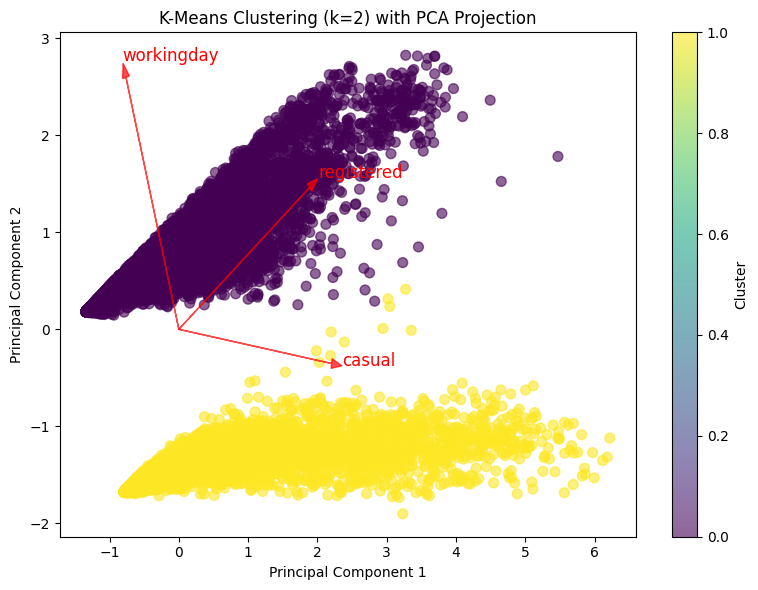

Explained variance by PCA components:
[0.58329451 0.30247086]

PCA Loadings:
                 PC1       PC2
atemp       0.632242  0.409732
weathersit -0.372030  0.905023
cnt         0.679605  0.114251


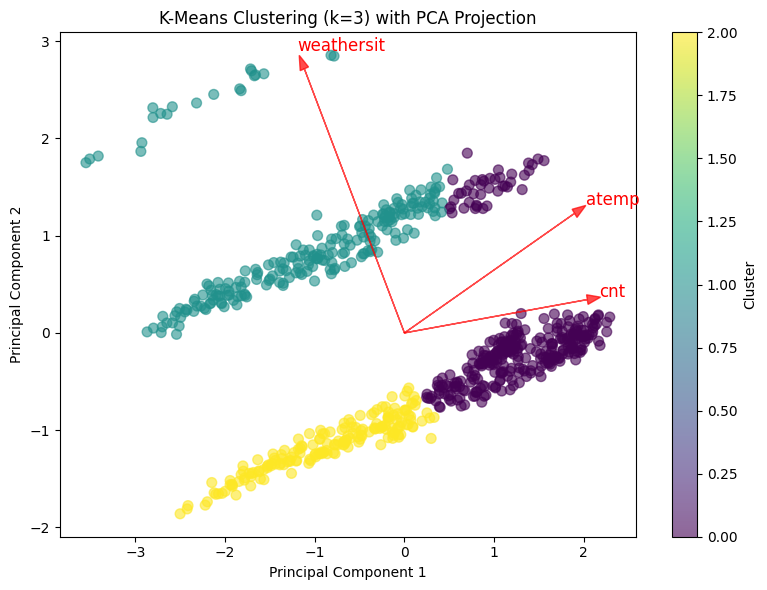

In [409]:
from sklearn.cluster import KMeans

# --- Select features for clustering ---
#features = ["temp", "hum", "windspeed", "hr", "weathersit", 'cnt']

def kmeans_and_plot(data, features, n_clusters=2, n_pca=2, show_arrows = True):

    X = data[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # --- K-Means clustering ---
    kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    data = data.copy()
    data["Cluster"] = labels
    
    # --- PCA for visualization ---
    pca = PCA(n_components=n_pca)
    X_pca = pca.fit_transform(X_scaled)
    
    print("Explained variance by PCA components:")
    print(pca.explained_variance_ratio_)
    
    # --- PCA loadings ---
    loadings = pd.DataFrame(
        pca.components_.T,            # transpose so rows = features
        index=features,               # rows = features
        columns=[f'PC{i+1}' for i in range(n_pca)]  # columns = PCs
    )
    print("\nPCA Loadings:")
    print(loadings)
    
    # --- Plot clusters ---
    plt.figure(figsize=(8,6))
    plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=labels,
        cmap="viridis",
        s=50,
        alpha=0.6
    )
    
    # --- Add PCA arrows ---
    if show_arrows:
        for i, feature in enumerate(features):
            plt.arrow(
                0, 0,  # start at origin
                loadings.iloc[i,0]*3,  # scale factor for visibility
                loadings.iloc[i,1]*3,
                color='red',
                alpha=0.7,
                head_width=0.1
            )
            plt.text(
                loadings.iloc[i,0]*3.2,
                loadings.iloc[i,1]*3.2,
                feature,
                color='red',
                fontsize=12
            )
            
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(f"K-Means Clustering (k={n_clusters}) with PCA Projection")
    plt.colorbar(label="Cluster")
    plt.tight_layout()
    plt.show()
    
    return 

task1 = ["casual","registered", "workingday"]
kmeans_and_plot(data_hour, task1, n_clusters=2, n_pca=2)


task2 = ["atemp", "weathersit", "cnt"]
kmeans_and_plot(data_day, task2, n_clusters=3, n_pca=2)

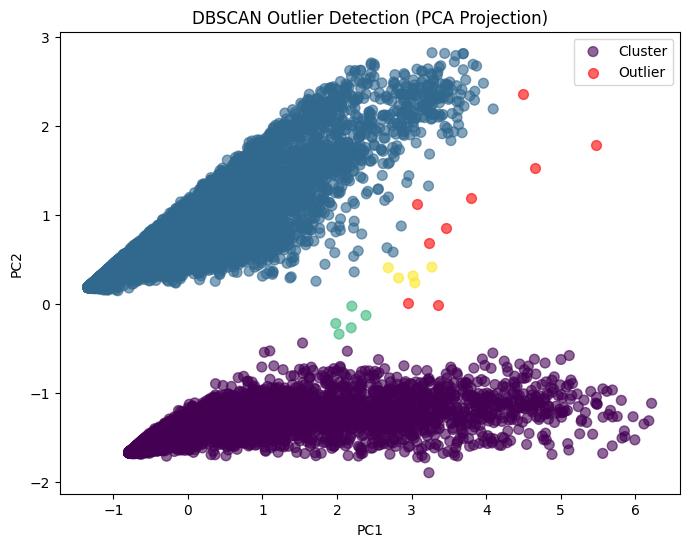

In [402]:
# DBSCAN for outlier deterction 
from sklearn.cluster import DBSCAN

def dbscan_outlier_detection(data, features, eps=0.5, min_samples=5, scale=True, plot=True):
    X = data[features].copy()

    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X.values
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    
    data = data.copy()
    data['DBSCAN_Label'] = labels

    if plot:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        
        plt.figure(figsize=(8,6))
        plt.scatter(
            X_pca[labels != -1, 0],
            X_pca[labels != -1, 1],
            c=labels[labels != -1],
            cmap='viridis',
            s=50,
            alpha=0.6,
            label='Cluster'
        )
        plt.scatter(
            X_pca[labels == -1, 0],
            X_pca[labels == -1, 1],
            c='red',
            s=50,
            alpha=0.6,
            label='Outlier'
        )
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title("DBSCAN Outlier Detection (PCA Projection)")
        plt.legend()
        plt.show()

    return 
features = ["casual", "registered", "workingday"]
dbscan_outlier_detection(data_hour,features=features,)


## 3. Module 2 — Graph-Based Analysis

In [313]:
import networkx as nx

# Build graph
G = nx.Graph()

## 4. Module 3 — Pattern / Text Mining

In [314]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
